# Figure 3b, c: Conductance Fluctuations
2D histogram and 1D histograms showing conductance fluctuations at different setpoint currents

In [13]:
import os
import numpy as np
import xarray as xr
import holoviews as hv
import rhkpy
import requests

hv.extension('matplotlib')

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

In [14]:
import sys
print(f'Python version: {sys.version}')
print(f'numpy version: {np.__version__}')
print(f'xarray version: {xr.__version__}')
print(f'holoviews version: {hv.__version__}')
print(f'rhkpy version: {rhkpy.__version__}')

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
numpy version: 2.3.1
xarray version: 2025.6.1
holoviews version: 1.21.0
rhkpy version: 1.3.9


In [15]:
# Download source files from Zenodo if missing
ZENODO_FILES = {
    'iz_map_out.sm4': 'https://zenodo.org/records/17469441/files/Stripes-9K-HOPG-SPI2-3_2021_09_09_05_50_41_043.sm4?download=1',
    'iz_map_in2.sm4': 'https://zenodo.org/records/17469441/files/MK_ABC_FLG_25_9K_2023_10_19_11_29_53_727.sm4?download=1',
    'iz_map_in3.sm4': 'https://zenodo.org/records/17469441/files/MK_ABC_FLG_25_9K_2023_10_24_10_15_58_878.sm4?download=1',
    'iz_map_in4.sm4': 'https://zenodo.org/records/17469441/files/MK_ABC_FLG_25_9K_2023_11_08_06_52_20_288.sm4?download=1',
}

for local, url in ZENODO_FILES.items():
    if url is None or os.path.exists(local):
        continue
    print(f'Downloading {local}...')
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    with open(local, 'wb') as fh:
        fh.write(response.content)
    print(f'✓ {local} downloaded')

In [16]:
# Helper function to process I-Z map data
def process_iz_map(filename):
    """Load and process I-Z map data"""
    iz_map = rhkpy.rhkdata(filename)
    iz_up = iz_map.spectra.current.sel(zscandir='up')
    iz_up['z'] = iz_up.z[::-1].data
    
    # Stack all spectra dimensions
    iz_up = iz_up.stack(allspec=('repetitions', 'specpos_x', 'specpos_y'))
    iz_up = iz_up.drop_vars(['specpos_x', 'specpos_y', 'repetitions'])
    iz_up = iz_up.assign_coords(allspec=iz_up['allspec'])
    iz_up['z'] = iz_up['z'] * 10
    iz_up['z'] = iz_up.z[::-1].data
    iz_up.data = np.abs(iz_up.data)
    
    return iz_map, iz_up

# Load and process all datasets
iz_map_out, iz_out_up = process_iz_map('iz_map_out.sm4')
iz_map_in2, iz_in2_up = process_iz_map('iz_map_in2.sm4')
iz_map_in3, iz_in3_up = process_iz_map('iz_map_in3.sm4')
iz_map_in4, iz_in4_up = process_iz_map('iz_map_in4.sm4')

In [17]:
# Calculate conductance fluctuations for all datasets
iz_out_mean = iz_out_up.mean(dim='allspec')
iz_in2_mean = iz_in2_up.mean(dim='allspec')
iz_in3_mean = iz_in3_up.mean(dim='allspec')
iz_in4_mean = iz_in4_up.mean(dim='allspec')

iz_out_fluct = np.abs((iz_out_up - iz_out_mean) / iz_map_out.spectra.attrs['bias'])
iz_in2_fluct = np.abs((iz_in2_up - iz_in2_mean) / iz_map_in2.spectra.attrs['bias'])
iz_in3_fluct = np.abs((iz_in3_up - iz_in3_mean) / iz_map_in3.spectra.attrs['bias'])
iz_in4_fluct = np.abs((iz_in4_up - iz_in4_mean) / iz_map_in4.spectra.attrs['bias'])

# Rename and set units
for fluct_data in [iz_out_fluct, iz_in2_fluct, iz_in3_fluct, iz_in4_fluct]:
    fluct_data.name = 'conductance'
    fluct_data.attrs['dimensions'] = 'pS'

In [18]:
# Create 2D histogram of conductance fluctuations vs distance
global_min = iz_in4_fluct.min().values
global_max = iz_in4_fluct.max().values
hist_data = []
for z_val in iz_in4_fluct['z'].values:
    current_data = iz_in4_fluct.sel(z=z_val).values
    hist, bin_edges = np.histogram(current_data, bins=500, range=(global_min, global_max))
    hist_data.append(hist)

hist_data = np.array(hist_data)
current_bins = (bin_edges[:-1] + bin_edges[1:]) / 2
hist_da = xr.DataArray(
    hist_data.T, 
    coords=[current_bins, iz_in4_fluct['z'].values], 
    dims=['current', 'z'],
    name='counts'
)

:Image   [z,current]   (counts)
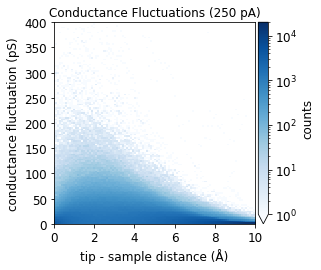

In [19]:
# Create plot with matplotlib backend
hist_fluct_plot = hv.Image(hist_da, kdims=['z', 'current']).opts(
    logz=True,
    cmap='blues',
    xlabel='tip - sample distance (Å)',
    ylabel='conductance fluctuation (pS)',
    clabel='counts',
    xlim=(0, 10),
    ylim=(0, 400),
    colorbar=True,
    aspect=1,
    fig_inches=4,
    title='Conductance Fluctuations (250 pA)',
    fontsize={'title': 12, 'labels': 12, 'xticks': 12, 'yticks': 12, 'cticks': 12}
)
hist_fluct_plot

:Overlay
   .Histogram.I   :Histogram   [conductance]   (Count)
   .Histogram.II  :Histogram   [conductance]   (Count)
   .Histogram.III :Histogram   [conductance]   (Count)
   .Histogram.IV  :Histogram   [conductance]   (Count)
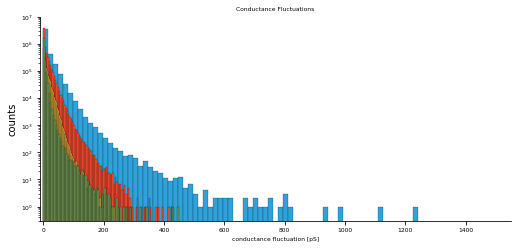

In [20]:
# Create 1D conductance fluctuation histograms (overlay)
hist_opts = dict(
    logy=True,
    color='blue',
    xlabel='conductance fluctuation [pS]',
    ylabel='counts',
    xlim=(-10, 1550),
    ylim=(0.3, 1e7),
    linewidth=0.2,
    aspect=1,
    fig_inches=1
)

plot_80 = iz_out_fluct.hvplot.hist('conductance', bins=100, bin_range=(0, 1500), label='80 pA').opts(**hist_opts)
plot_150 = iz_in2_fluct.hvplot.hist('conductance', bins=100, bin_range=(0, 1500), label='150 pA').opts(**hist_opts)
plot_200 = iz_in3_fluct.hvplot.hist('conductance', bins=100, bin_range=(0, 1500), label='200 pA').opts(**hist_opts)
plot_250 = iz_in4_fluct.hvplot.hist('conductance', bins=100, bin_range=(0, 1500), label='250 pA').opts(**hist_opts)

plot_all_hist = (plot_250 * plot_200 * plot_150 * plot_80).opts(
    title='Conductance Fluctuations',
    fontsize={'title': 6, 'labels': 6, 'xticks': 6, 'yticks': 6, 'legend': 6}
)
plot_all_hist

In [21]:
# hv.save(plot_all_hist, 'fig3b_conductance_hist_overlay.svg', fmt='svg')

In [22]:
# hv.save(hist_fluct_plot, 'fig3b_conductance_fluct_2d.svg', fmt='svg')